  # Face Swap Experiment Report

  This notebook presents a three-stage experiment:

  1. **Face swapping**
  2. **Pairwise identity comparison in embedding space**
  3. **Nearest-neighbor retrieval in the FFHQ gallery**

  The goal is to evaluate whether face-swapped images:

  - move away from the original target identity,
  - move toward the inserted reference identity,
  - and become difficult to associate with the original identity in a larger retrieval setting.

## Imports + style setup

In [1]:
  from pathlib import Path
  import base64
  import io
  import json
  import re
  import subprocess
  import sys

  import cv2
  import numpy as np
  import pandas as pd
  from IPython.display import HTML, Markdown, display
  from PIL import Image
  from tqdm.notebook import tqdm
  import ipywidgets as widgets

  def find_repo_root(start=None):
      start = Path.cwd().resolve() if start is None else Path(start).resolve()
      for candidate in [start, *start.parents]:
          if (candidate / "facefusion").exists() and (candidate / "face-swap-experiment").exists():
              return candidate
      raise RuntimeError("Could not locate repo root")

  ROOT = find_repo_root()
  EXPERIMENT_DIR = ROOT / "face-swap-experiment"
  REPORTS_DIR = EXPERIMENT_DIR / "reports"
  ASSETS_DIR = REPORTS_DIR / "notebook_assets"
  INPUT_DIR = ROOT / "test-img"

  display(HTML("""
  <style>
  html, body, .jp-Notebook, .jp-RenderedMarkdown, .jp-OutputArea-output {
      font-size: 18px !important;
      line-height: 1.65 !important;
  }
  .jp-RenderedMarkdown h1 { font-size: 2.2rem !important; margin-top: 0.6em; }
  .jp-RenderedMarkdown h2 { font-size: 1.7rem !important; margin-top: 1.2em; }
  .jp-RenderedMarkdown h3 { font-size: 1.35rem !important; margin-top: 1.0em; }

  .report-note {
      background: linear-gradient(135deg, #f6f8ff 0%, #eef4ff 100%);
      border: 1px solid #d7e3ff;
      border-left: 6px solid #5b7cfa;
      border-radius: 10px;
      padding: 14px 18px;
      margin: 14px 0;
  }
  .report-warn {
      background: linear-gradient(135deg, #fff8ef 0%, #fff4e7 100%);
      border: 1px solid #ffd8a8;
      border-left: 6px solid #f08c00;
      border-radius: 10px;
      padding: 14px 18px;
      margin: 14px 0;
  }
  .scroll-box {
      max-height: 920px;
      overflow-y: auto;
      border: 1px solid #d8dee9;
      border-radius: 10px;
      padding: 12px;
      background: #fbfcff;
  }
  .metric-card {
      display: inline-block;
      min-width: 220px;
      margin: 8px 12px 8px 0;
      padding: 14px 16px;
      border-radius: 10px;
      background: linear-gradient(135deg, #f8f9ff 0%, #eef2ff 100%);
      border: 1px solid #dbe4ff;
      box-shadow: 0 2px 8px rgba(0,0,0,0.04);
  }
  .metric-title {
      font-size: 0.9rem;
      color: #4c566a;
      margin-bottom: 6px;
  }
  .metric-value {
      font-size: 1.4rem;
      font-weight: 700;
      color: #1f2a44;
  }
  table.dataframe td, table.dataframe th {
      font-size: 16px !important;
      padding: 8px 10px !important;
  }
  </style>
  """))

  def png_to_html(path, max_width="100%"):
      path = Path(path)
      data = base64.b64encode(path.read_bytes()).decode("utf-8")
      return f'<img src="data:image/png;base64,{data}" style="max-width:{max_width}; height:auto;">'

  def show_png(path, max_width="100%"):
      display(HTML(png_to_html(path, max_width=max_width)))

  def show_scrollable_png(path, max_width="100%"):
      display(HTML(f'<div class="scroll-box">{png_to_html(path, max_width=max_width)}</div>'))

  def styled_table(df, precision=4):
      return (
          df.style
          .format(precision=precision)
          .set_table_styles([
              {"selector": "th", "props": [("background-color", "#eef2ff"), ("color", "#1f2a44")]},
              {"selector": "td", "props": [("border-color", "#d8dee9")]},
          ])
      )

  def run_python_script(script_path, title, progress_total=None, progress_pattern=None):
      script_path = Path(script_path)
      cmd = [sys.executable, str(script_path)]
      print(f"Running: {' '.join(cmd)}")

      bar = None
      if progress_total is not None:
          bar = tqdm(total=progress_total, desc=title, unit="step")

      process = subprocess.Popen(
          cmd,
          cwd=str(ROOT),
          stdout=subprocess.PIPE,
          stderr=subprocess.STDOUT,
          text=True,
          bufsize=1,
      )

      for line in process.stdout:
          print(line, end="")
          if bar is not None and progress_pattern is not None:
              match = re.search(progress_pattern, line)
              if match:
                  value = int(match.group(1))
                  bar.n = min(value, bar.total)
                  bar.refresh()

      process.wait()

      if bar is not None:
          if process.returncode == 0:
              bar.n = bar.total
              bar.refresh()
          bar.close()

      if process.returncode != 0:
          raise RuntimeError(f"{script_path.name} failed with exit code {process.returncode}")

  print("ROOT:", ROOT)
  print("EXPERIMENT_DIR:", EXPERIMENT_DIR)

ROOT: /srv/filaka-shared/diploma-new
EXPERIMENT_DIR: /srv/filaka-shared/diploma-new/face-swap-experiment


  # 1. Face Swapping

  This chapter presents the face-swapping stage of the experiment.

  The experiment uses:

  - **10 target images**: `female1..5`, `male1..5`
  - **2 reference faces**: `female_prot.png`, `male_prot.png`
  - **4 face-swapping models**
  - **15 model/preset configurations**
  - **150 generated swapped images**

  ## How to read the experiment labels

  For presentation, it is better to read experiment names in the following form:

  - **HyperSwap 1A / Preset A / Baseline**
  - **HyperSwap 1A / Preset B / Strong identity replacement**
  - **HyperSwap 1A / Preset C / Smoother boundary**
  - **HyperSwap 1A / Preset D / High detail**
  - **HyperSwap 1A / Preset E / Enhanced output**
  - **HyperSwap 1C / Preset A / Baseline**
  - **HyperSwap 1C / Preset B / Strong identity replacement**
  - **HyperSwap 1C / Preset D / High detail**
  - **InSwapper FP16 / Preset A / Baseline**
  - **InSwapper FP16 / Preset B / Strong identity replacement**
  - **InSwapper FP16 / Preset C / Smoother boundary**
  - **InSwapper FP16 / Preset E / Enhanced output**
  - **SimSwap 512 / Preset A / Baseline**
  - **SimSwap 512 / Preset B / Strong identity replacement**
  - **SimSwap 512 / Preset D / High detail workaround (1024x1024)**

  The table below summarizes the technical conditions of each experiment.

In [2]:
  conditions = pd.DataFrame([
      ["hyperswap_1a_256", "preset_A", "512x512", 0.8, "box+occlusion", 0.3, "0 0 0 0", "face_swapper"],
      ["hyperswap_1a_256", "preset_B", "512x512", 1.0, "box+occlusion", 0.3, "10 10 10 10", "face_swapper"],
      ["hyperswap_1a_256", "preset_C", "512x512", 0.9, "box+occlusion", 0.5, "15 15 15 15", "face_swapper"],
      ["hyperswap_1a_256", "preset_D", "768x768", 1.0, "box+occlusion", 0.3, "10 10 10 10", "face_swapper"],
      ["hyperswap_1a_256", "preset_E", "512x512", 0.9, "box+occlusion", 0.3, "10 10 10 10", "face_swapper + face_enhancer"],

      ["hyperswap_1c_256", "preset_A", "512x512", 0.8, "box+occlusion", 0.3, "0 0 0 0", "face_swapper"],
      ["hyperswap_1c_256", "preset_B", "512x512", 1.0, "box+occlusion", 0.3, "10 10 10 10", "face_swapper"],
      ["hyperswap_1c_256", "preset_D", "768x768", 1.0, "box+occlusion", 0.3, "10 10 10 10", "face_swapper"],

      ["inswapper_128_fp16", "preset_A", "512x512", 0.8, "box+occlusion", 0.3, "0 0 0 0", "face_swapper"],
      ["inswapper_128_fp16", "preset_B", "512x512", 1.0, "box+occlusion", 0.3, "10 10 10 10", "face_swapper"],
      ["inswapper_128_fp16", "preset_C", "512x512", 0.9, "box+occlusion", 0.5, "15 15 15 15", "face_swapper"],
      ["inswapper_128_fp16", "preset_E", "512x512", 0.9, "box+occlusion", 0.3, "10 10 10 10", "face_swapper + face_enhancer"],

      ["simswap_unofficial_512", "preset_A", "512x512", 0.8, "box+occlusion", 0.3, "0 0 0 0", "face_swapper"],
      ["simswap_unofficial_512", "preset_B", "512x512", 1.0, "box+occlusion", 0.3, "10 10 10 10", "face_swapper"],
      ["simswap_unofficial_512", "preset_D_1024x1024", "1024x1024", 1.0, "box+occlusion", 0.3, "10 10 10 10", "face_swapper"],
  ], columns=[
      "model", "preset", "pixel_boost", "swapper_weight", "mask_types", "mask_blur", "mask_padding", "processors"
  ])

  display(HTML("""
  <div class="report-note">
  <b>Presentation note.</b> SimSwap does not use the nominal <code>768x768</code> high-detail setting here.
  The valid high-detail run is stored as <code>preset_D_1024x1024</code>.
  </div>
  """))

  display(
      conditions.style
      .hide(axis="index")
      .set_table_styles([
          {"selector": "th", "props": [("background-color", "#e8efff"), ("color", "#1f2a44"), ("font-size", "16px")]},
          {"selector": "td", "props": [("font-size", "15px"), ("padding", "8px 10px")]},
      ])
  )

model,preset,pixel_boost,swapper_weight,mask_types,mask_blur,mask_padding,processors
hyperswap_1a_256,preset_A,512x512,0.800000,box+occlusion,0.300000,0 0 0 0,face_swapper
hyperswap_1a_256,preset_B,512x512,1.000000,box+occlusion,0.300000,10 10 10 10,face_swapper
hyperswap_1a_256,preset_C,512x512,0.900000,box+occlusion,0.500000,15 15 15 15,face_swapper
hyperswap_1a_256,preset_D,768x768,1.000000,box+occlusion,0.300000,10 10 10 10,face_swapper
hyperswap_1a_256,preset_E,512x512,0.900000,box+occlusion,0.300000,10 10 10 10,face_swapper + face_enhancer
hyperswap_1c_256,preset_A,512x512,0.800000,box+occlusion,0.300000,0 0 0 0,face_swapper
hyperswap_1c_256,preset_B,512x512,1.000000,box+occlusion,0.300000,10 10 10 10,face_swapper
hyperswap_1c_256,preset_D,768x768,1.000000,box+occlusion,0.300000,10 10 10 10,face_swapper
inswapper_128_fp16,preset_A,512x512,0.800000,box+occlusion,0.300000,0 0 0 0,face_swapper
inswapper_128_fp16,preset_B,512x512,1.000000,box+occlusion,0.300000,10 10 10 10,face_swapper


  ## Visual Results

  The viewer below is intentionally organized as a **single scrollable experiment panel** to reduce presentation-time scrolling.

  ### How to read each panel

  - **first column**: reference face used for insertion
  - **remaining columns**: swapped outputs for the selected experiment
  - **female row**: results for `female1..5`
  - **male row**: results for `male1..5`

## Source Images Before Face Swapping


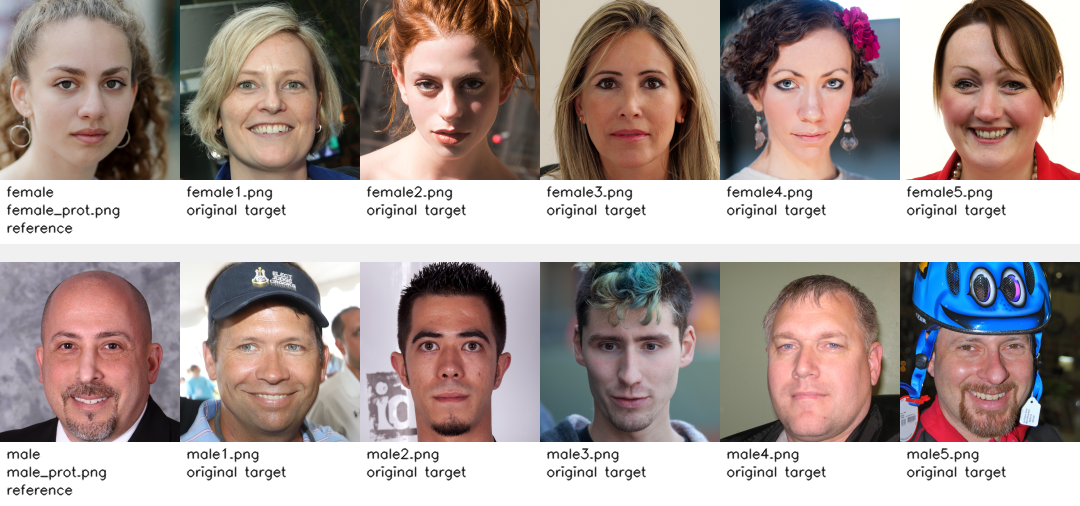

## Experiment Results

In [3]:
  display(Markdown("## Source Images Before Face Swapping"))
  show_png(ASSETS_DIR / "source_images_before_swapping.png")

  display(Markdown("## Experiment Results"))

  chapter1_assets = sorted(ASSETS_DIR.glob("*preset*.png"))
  chapter1_map = {p.stem: p for p in chapter1_assets if not p.stem.startswith("ffhq_retrieval_")}

  chapter1_dropdown = widgets.Dropdown(
      options=sorted(chapter1_map.keys()),
      description="Experiment:",
      layout=widgets.Layout(width="520px")
  )

  chapter1_out = widgets.Output()

  def render_chapter1(change=None):
      with chapter1_out:
          chapter1_out.clear_output()
          key = chapter1_dropdown.value
          display(HTML("""
          <div class="report-note">
          First column: reference face. Remaining columns: swapped outputs for the selected experiment.
          </div>
          """))
          show_scrollable_png(chapter1_map[key], max_width="100%")

  chapter1_dropdown.observe(render_chapter1, names="value")
  render_chapter1()

  display(widgets.VBox([chapter1_dropdown, chapter1_out]))

  # 2. Cosine Comparing

  This chapter evaluates identity change in embedding space using two pretrained face-recognition models:

  - **ArcFace**
  - **AdaFace**

  For each swapped image, two pairwise comparisons are measured:

  - **original -> modified**
  - **reference -> modified**

  ## Cosine distance used in this notebook

  The metric is defined as:

  $$
  d = 1 - \cos(\theta)
  $$

  where:

  - $d$ is cosine distance
  - $\cos(\theta)$ is cosine similarity between two embeddings

  ## Valid range

  Because cosine similarity is in the interval $[-1, 1]$, cosine distance is in the interval:

  $$
  [0, 2]
  $$

  This means that values larger than **1.0** are mathematically valid.

  ### Interpretation

  - **smaller distance** = more similar embeddings
  - **larger distance** = less similar embeddings
  - **distance > 1** = negative cosine similarity

## Cosine distances calculation

In [4]:
  results_csv = REPORTS_DIR / "face_similarity_results.csv"
  summary_csv = REPORTS_DIR / "face_similarity_summary.csv"
  combined_csv = REPORTS_DIR / "face_similarity_combined_summary.csv"

  if not results_csv.exists() or not summary_csv.exists() or not combined_csv.exists():
      run_python_script(
          EXPERIMENT_DIR / "compute_face_metrics.py",
          title="Stage 2: pairwise embedding comparison"
      )
  else:
      print("Stage 2 CSV files already exist.")

Stage 2 CSV files already exist.


## Results

  ## How to read the table colors

  The summary tables use color gradients to make the comparison faster during demonstration.

  ### Blue scale
  Used for:

  - `mean_original_distance`
  - `mean_identity_replacement_score`

  Interpretation:

  - **darker blue** = larger value
  - for `mean_original_distance`, darker blue means the swapped image is **farther from the original target**
  - for `mean_identity_replacement_score`, darker blue means **stronger identity replacement**

  ### Orange scale
  Used for:

  - `mean_reference_distance`

  Interpretation:

  - **lighter orange** = smaller value
  - smaller `mean_reference_distance` means the swapped image is **closer to the reference identity**
  - darker orange means the swap is less faithful to the reference identity

  ## Practical reading rule

  The most desirable rows are those with:

  - **dark blue** in `mean_original_distance`
  - **dark blue** in `mean_identity_replacement_score`
  - **light orange** in `mean_reference_distance`

In [11]:
  results = pd.read_csv(results_csv)
  summary = pd.read_csv(summary_csv)
  combined = pd.read_csv(combined_csv)

  similarity_check = pd.DataFrame({
      "recognizer": results["recognizer"],
      "cos_similarity_original_modified": results["cos_similarity_original_modified"],
      "cos_similarity_reference_modified": results["cos_similarity_reference_modified"],
      "cos_distance_original_modified": results["cos_distance_original_modified"],
      "cos_distance_reference_modified": results["cos_distance_reference_modified"],
  })

  range_df = pd.DataFrame([
      [
          "ArcFace",
          results.loc[results.recognizer == "arcface", "cos_similarity_original_modified"].min(),
          results.loc[results.recognizer == "arcface", "cos_similarity_original_modified"].max(),
          results.loc[results.recognizer == "arcface", "cos_distance_original_modified"].min(),
          results.loc[results.recognizer == "arcface", "cos_distance_original_modified"].max(),
      ],
      [
          "AdaFace",
          results.loc[results.recognizer == "adaface", "cos_similarity_original_modified"].min(),
          results.loc[results.recognizer == "adaface", "cos_similarity_original_modified"].max(),
          results.loc[results.recognizer == "adaface", "cos_distance_original_modified"].min(),
          results.loc[results.recognizer == "adaface", "cos_distance_original_modified"].max(),
      ],
  ], columns=[
      "recognizer",
      "min_similarity",
      "max_similarity",
      "min_distance",
      "max_distance"
  ])

  display(Markdown("## Metric Range Check"))
  display(styled_table(range_df))

  best = combined.iloc[0]
  display(HTML(f"""
  <div class="metric-card">
    <div class="metric-title">Best setup</div>
    <div class="metric-value">{best['model']} / {best['preset']}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">Mean original → modified distance</div>
    <div class="metric-value">{best['mean_original_distance']:.4f}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">Mean reference → modified distance</div>
    <div class="metric-value">{best['mean_reference_distance']:.4f}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">Mean identity replacement score</div>
    <div class="metric-value">{best['mean_identity_replacement_score']:.4f}</div>
  </div>
  """))

  display(Markdown("## Per-recognizer Summary"))
  display(
      summary.sort_values(["recognizer", "mean_identity_replacement_score"], ascending=[True, False])
      .style
      .format(precision=4)
      .background_gradient(subset=["mean_original_distance", "mean_identity_replacement_score"], cmap="Blues")
      .background_gradient(subset=["mean_reference_distance"], cmap="Oranges_r")
  )

  display(Markdown("## Combined Ranking"))
  display(
      combined.style
      .format(precision=4)
      .background_gradient(subset=["mean_identity_replacement_score"], cmap="Blues")
      .background_gradient(subset=["mean_reference_distance"], cmap="Oranges_r")
  )

## Metric Range Check

,recognizer,min_similarity,max_similarity,min_distance,max_distance
0,ArcFace,-0.0988,0.3837,0.6163,1.0988
1,AdaFace,-0.0963,0.3181,0.6819,1.0963


## Per-recognizer Summary

,model,preset,preset_label,recognizer,mean_original_distance,mean_reference_distance,mean_original_similarity,mean_reference_similarity,mean_identity_replacement_score,min_original_distance,max_reference_distance,image_count
0,hyperswap_1c_256,preset_D,D - high detail,adaface,1.0179,0.2518,-0.0179,0.7482,0.7662,0.9101,0.3176,10
1,hyperswap_1c_256,preset_B,B - strong identity replacement,adaface,1.0140,0.2541,-0.0140,0.7459,0.7599,0.9101,0.3295,10
2,hyperswap_1a_256,preset_D,D - high detail,adaface,0.9941,0.2442,0.0059,0.7558,0.7499,0.9073,0.3266,10
3,hyperswap_1a_256,preset_B,B - strong identity replacement,adaface,0.9910,0.2458,0.0090,0.7542,0.7452,0.9033,0.3282,10
4,hyperswap_1c_256,preset_A,A - baseline,adaface,0.9743,0.2366,0.0257,0.7634,0.7377,0.8683,0.3144,10
5,hyperswap_1a_256,preset_A,A - baseline,adaface,0.9512,0.2293,0.0488,0.7707,0.7219,0.8646,0.3078,10
6,hyperswap_1a_256,preset_C,C - smoother boundary,adaface,0.9591,0.2474,0.0409,0.7526,0.7117,0.8718,0.3277,10
7,hyperswap_1a_256,preset_E,E - enhanced output,adaface,0.9593,0.2486,0.0407,0.7514,0.7108,0.8662,0.3339,10
8,inswapper_128_fp16,preset_A,A - baseline,adaface,0.8856,0.2088,0.1144,0.7912,0.6767,0.8303,0.2711,10
9,inswapper_128_fp16,preset_B,B - strong identity replacement,adaface,0.8922,0.2255,0.1078,0.7745,0.6668,0.8340,0.2838,10


## Combined Ranking

,model,preset,preset_label,mean_original_distance,mean_reference_distance,mean_identity_replacement_score,arcface_score,image_count
0,hyperswap_1c_256,preset_D,D - high detail,1.0225,0.2351,0.7874,0.7662,10
1,hyperswap_1c_256,preset_B,B - strong identity replacement,1.0187,0.2374,0.7812,0.7599,10
2,hyperswap_1a_256,preset_D,D - high detail,1.0022,0.2297,0.7725,0.7499,10
3,hyperswap_1a_256,preset_B,B - strong identity replacement,0.9992,0.2316,0.7676,0.7452,10
4,hyperswap_1c_256,preset_A,A - baseline,0.9735,0.2228,0.7507,0.7377,10
5,hyperswap_1a_256,preset_A,A - baseline,0.9550,0.2171,0.7380,0.7219,10
6,hyperswap_1a_256,preset_E,E - enhanced output,0.9661,0.2370,0.7291,0.7108,10
7,hyperswap_1a_256,preset_C,C - smoother boundary,0.9635,0.2354,0.7281,0.7117,10
8,inswapper_128_fp16,preset_A,A - baseline,0.8802,0.1861,0.6941,0.6767,10
9,inswapper_128_fp16,preset_B,B - strong identity replacement,0.8867,0.2034,0.6833,0.6668,10


  # 3. FFHQ Retrieval

  This chapter tests whether the identity modification is strong enough to affect **nearest-neighbor retrieval** in a larger face
  gallery.

  Pairwise distance alone is not sufficient for the final claim.
  A stronger test is whether a swapped image still retrieves the same nearest gallery identity as the original target image.

  ## Stage 3 structure

  This stage is divided into three parts:

  1. **FFHQ preprocessing**
  2. **gallery-index construction**
  3. **top-5 retrieval analysis for swapped images**

  ## 3.1 FFHQ Preprocessing

  The FFHQ archive is first preprocessed before retrieval begins.

  ### Preprocessing logic

  1. read candidate images from `ffhq.tar.gz`
  2. detect faces with **FaceFusion** using the configured **YOLO Face detector** and **2DFAN4 landmarker**
  3. keep only images where FaceFusion estimates a **frontal face**
  4. compute **ArcFace** and **AdaFace** gallery embeddings for the retained images
  5. save the gallery manifest and embedding index for later retrieval

  ### Frontal-face rule used here

  A gallery image is included only when FaceFusion estimates:

  - `face.angle == 0`

  This is a practical frontal-face filter for the current experiment.

  ### Dataset statistics after preprocessing

  - FFHQ image files in `Part1`: **4866**
  - retained frontal FFHQ faces: **4865**
  - excluded from the usable gallery: **1 image**
  - retained gallery gender split: **2541 female**, **2324 male**

  ### Why this preprocessing is necessary

  The goal is to avoid comparing the swapped images against side-view or strongly rotated faces, because the target experiment
  itself is centered on frontal or near-frontal portrait inputs.

In [6]:
  import csv
  import tarfile
  from collections import Counter
  from pathlib import Path
  from IPython.display import display
  import pandas as pd

  ROOT = Path.cwd()
  for candidate in [ROOT, *ROOT.parents]:
      if (candidate / "face-swap-experiment").exists():
          ROOT = candidate
          break

  REPORTS_DIR = ROOT / "face-swap-experiment" / "reports"
  FFHQ_ARCHIVE = ROOT / "ffhq.tar.gz"

  part1_png_files = 0
  with tarfile.open(FFHQ_ARCHIVE, "r:gz") as tar:
      for member in tar:
          if member.isfile() and member.name.startswith("ffhq/Part1/") and member.name.endswith(".png"):
              part1_png_files += 1

  manifest_rows = []
  with (REPORTS_DIR / "ffhq_gallery_manifest.csv").open(newline="") as f:
      reader = csv.DictReader(f)
      manifest_rows = list(reader)

  retained_count = len(manifest_rows)
  excluded_count = part1_png_files - retained_count
  gender_counts = Counter(row["gender"] for row in manifest_rows)

  stats_df = pd.DataFrame([
      ["FFHQ image files in Part1", part1_png_files],
      ["Retained frontal FFHQ faces", retained_count],
      ["Excluded from usable gallery", excluded_count],
      ["Retained female faces", gender_counts.get("female", 0)],
      ["Retained male faces", gender_counts.get("male", 0)],
  ], columns=["Statistic", "Value"])

  display(stats_df)

,Statistic,Value
0,FFHQ image files in Part1,4866
1,Retained frontal FFHQ faces,4865
2,Excluded from usable gallery,1
3,Retained female faces,2541
4,Retained male faces,2324


In [7]:
  gallery_manifest_csv = REPORTS_DIR / "ffhq_gallery_manifest.csv"
  gallery_npz = REPORTS_DIR / "ffhq_gallery_embeddings.npz"
  retrieval_results_csv = REPORTS_DIR / "ffhq_retrieval_results.csv"
  retrieval_query_summary_csv = REPORTS_DIR / "ffhq_retrieval_query_summary.csv"
  retrieval_experiment_summary_csv = REPORTS_DIR / "ffhq_retrieval_experiment_summary.csv"

  display(HTML("""
  <div class="report-note">
  <b>Preprocessing step.</b> This stage builds a frontal-face gallery from FFHQ and computes gallery embeddings before retrieval.
  </div>
  """))

  if not gallery_manifest_csv.exists() or not gallery_npz.exists() or not retrieval_results_csv.exists():
      run_python_script(
          EXPERIMENT_DIR / "compute_ffhq_retrieval.py",
          title="FFHQ frontal gallery indexing",
          progress_total=4865,
          progress_pattern=r"Indexed (\\d+) FFHQ frontal faces"
      )
  else:
      print("Stage 3 preprocessing/results already exist.")

Stage 3 preprocessing/results already exist.


  ## 3.2 Images Used in Retrieval

  The retrieval stage uses three image groups:

  ### Original target images
  These are the people before swapping:

  - `female1..5`
  - `male1..5`

  ### Swapped images
  These are the outputs from Stage 1 for each model/preset configuration.

  ### FFHQ gallery images
  These are external comparison images taken from the provided FFHQ archive after preprocessing.

  ## Retrieval logic

  For each target image:

  1. the original target image is matched to its nearest FFHQ identity
  2. the swapped image is then used as a new query
  3. the top-5 nearest FFHQ faces are retrieved
  4. the experiment checks whether the swapped image still retrieves the same FFHQ identity as the original target

## Used Images


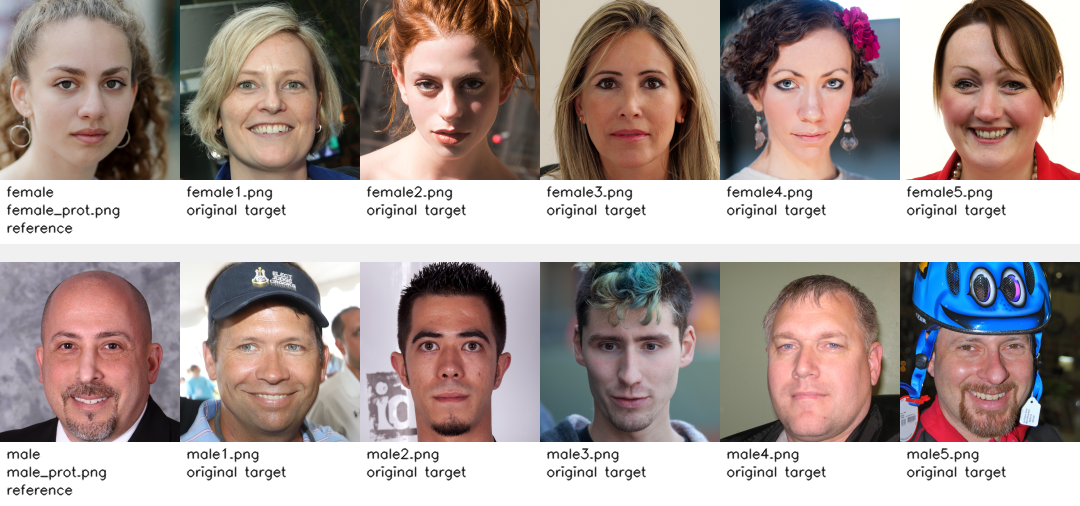

## Preprocessing Summary

,property,value
0,FFHQ source archive,ffhq.tar.gz
1,Gallery filter,FaceFusion frontal faces only (angle == 0)
2,Gallery manifest file,reports/ffhq_gallery_manifest.csv
3,Gallery embedding file,reports/ffhq_gallery_embeddings.npz
4,Detailed retrieval results,reports/ffhq_retrieval_results.csv
5,Experiment summary,reports/ffhq_retrieval_experiment_summary.csv


## First rows of the frontal FFHQ gallery manifest

,gallery_member_path,gallery_asset_path,face_angle,gender
0,ffhq/Part1/02205.png,reports/notebook_assets/ffhq_gallery/02205.png,0,female
1,ffhq/Part1/01793.png,reports/notebook_assets/ffhq_gallery/01793.png,0,male
2,ffhq/Part1/02854.png,reports/notebook_assets/ffhq_gallery/02854.png,0,male
3,ffhq/Part1/00303.png,reports/notebook_assets/ffhq_gallery/00303.png,0,female
4,ffhq/Part1/01719.png,reports/notebook_assets/ffhq_gallery/01719.png,0,female
5,ffhq/Part1/01950.png,reports/notebook_assets/ffhq_gallery/01950.png,0,male
6,ffhq/Part1/00897.png,reports/notebook_assets/ffhq_gallery/00897.png,0,male
7,ffhq/Part1/03869.png,reports/notebook_assets/ffhq_gallery/03869.png,0,male
8,ffhq/Part1/02192.png,reports/notebook_assets/ffhq_gallery/02192.png,0,female
9,ffhq/Part1/01008.png,reports/notebook_assets/ffhq_gallery/01008.png,0,male


## Gallery composition

,gender,size
0,female,2541
1,male,2324


In [8]:
  gallery_manifest = pd.read_csv(gallery_manifest_csv)
  retrieval_results = pd.read_csv(retrieval_results_csv)
  retrieval_query_summary = pd.read_csv(retrieval_query_summary_csv)
  retrieval_experiment_summary = pd.read_csv(retrieval_experiment_summary_csv)

  display(Markdown("## Used Images"))

  display(HTML("""
  <div class="report-note">
  <b>Target and reference images.</b> The experiment uses 10 targets and 2 reference identities from <code>test-img/</code>.
  </div>
  """))
  show_png(ASSETS_DIR / "source_images_before_swapping.png")

  display(HTML(f"""
  <div class="metric-card">
    <div class="metric-title">FFHQ frontal gallery size</div>
    <div class="metric-value">{len(gallery_manifest)}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">Stage 3 query count</div>
    <div class="metric-value">{len(retrieval_query_summary)}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">Detailed top-5 rows</div>
    <div class="metric-value">{len(retrieval_results)}</div>
  </div>
  """))

  display(Markdown("## Preprocessing Summary"))
  display(
      styled_table(
          pd.DataFrame({
              "property": [
                  "FFHQ source archive",
                  "Gallery filter",
                  "Gallery manifest file",
                  "Gallery embedding file",
                  "Detailed retrieval results",
                  "Experiment summary"
              ],
              "value": [
                  "ffhq.tar.gz",
                  "FaceFusion frontal faces only (angle == 0)",
                  "reports/ffhq_gallery_manifest.csv",
                  "reports/ffhq_gallery_embeddings.npz",
                  "reports/ffhq_retrieval_results.csv",
                  "reports/ffhq_retrieval_experiment_summary.csv",
              ]
          }),
          precision=4
      )
  )

  display(Markdown("## First rows of the frontal FFHQ gallery manifest"))
  display(styled_table(gallery_manifest.head(12), precision=4))

  display(Markdown("## Gallery composition"))
  display(styled_table(gallery_manifest.groupby("gender", as_index=False).size()))

  ## How to read the Chapter 3 colors

  The retrieval summary table also uses color gradients.

  ### Purple scale
  Used for:

  - `mean_source_gallery_distance`
  - `mean_top1_ranker_distance`

  Interpretation:

  - **darker purple** = larger distance
  - larger `mean_source_gallery_distance` means the swapped image is farther from the original target's nearest gallery identity
  - this is desirable for identity suppression

  ### Orange scale
  Used for:

  - `source_match_top1_rate`
  - `source_match_top5_rate`

  Interpretation:

  - **lighter orange** = smaller match rate
  - smaller values are better
  - `0.0` means the swapped image no longer retrieves the same gallery identity in that ranking condition

  ## Practical reading rule

  The most desirable rows are those with:

  - **dark purple** in distance columns
  - **light orange** in source-match columns

In [9]:
  display(Markdown("## Retrieval Summary"))

  best_arc = retrieval_experiment_summary[retrieval_experiment_summary["ranker_recognizer"] == "arcface"].iloc[0]
  best_ada = retrieval_experiment_summary[retrieval_experiment_summary["ranker_recognizer"] == "adaface"].iloc[0]

  display(HTML(f"""
  <div class="metric-card">
    <div class="metric-title">Best ArcFace setup</div>
    <div class="metric-value">{best_arc['model']} / {best_arc['preset']}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">ArcFace source match top-5 rate</div>
    <div class="metric-value">{best_arc['source_match_top5_rate']:.4f}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">Best AdaFace setup</div>
    <div class="metric-value">{best_ada['model']} / {best_ada['preset']}</div>
  </div>
  <div class="metric-card">
    <div class="metric-title">AdaFace source match top-5 rate</div>
    <div class="metric-value">{best_ada['source_match_top5_rate']:.4f}</div>
  </div>
  """))

  display(
      retrieval_experiment_summary.style
      .format(precision=4)
      .background_gradient(subset=["mean_source_gallery_distance", "mean_top1_ranker_distance"], cmap="Purples")
      .background_gradient(subset=["source_match_top1_rate", "source_match_top5_rate"], cmap="Oranges_r")
  )

## Retrieval Summary

,model,preset,ranker_recognizer,mean_top1_ranker_distance,mean_source_gallery_distance,source_match_top1_rate,source_match_top5_rate,image_count
0,hyperswap_1c_256,preset_D,adaface,0.2519,1.0180,0.0000,0.0000,10
1,hyperswap_1c_256,preset_B,adaface,0.2541,1.0139,0.0000,0.0000,10
2,hyperswap_1a_256,preset_D,adaface,0.2446,0.9941,0.0000,0.0000,10
3,hyperswap_1a_256,preset_B,adaface,0.2461,0.9907,0.0000,0.0000,10
4,hyperswap_1c_256,preset_A,adaface,0.2369,0.9741,0.0000,0.0000,10
5,hyperswap_1a_256,preset_E,adaface,0.2488,0.9594,0.0000,0.0000,10
6,hyperswap_1a_256,preset_C,adaface,0.2475,0.9591,0.0000,0.0000,10
7,hyperswap_1a_256,preset_A,adaface,0.2295,0.9509,0.0000,0.0000,10
8,inswapper_128_fp16,preset_B,adaface,0.2252,0.8922,0.0000,0.0000,10
9,inswapper_128_fp16,preset_E,adaface,0.2385,0.8861,0.0000,0.0000,10


  ## 3.3 Visual Retrieval Results

  The viewer below is organized as a **single scrollable retrieval panel** to reduce scrolling during presentation.

  ### How to read each retrieval row

  - **column 1**: original target image
  - **column 2**: swapped image
  - **columns 3-7**: top-5 nearest FFHQ faces

  Each retrieved match also shows two distances:

  - **A** = ArcFace cosine distance
  - **D** = AdaFace cosine distance

  This allows visual inspection together with numerical comparison.

In [10]:
  display(Markdown("## Retrieval Visual Results"))

  retrieval_assets = sorted(ASSETS_DIR.glob("ffhq_retrieval_*.png"))
  retrieval_map = {p.stem: p for p in retrieval_assets}

  retrieval_dropdown = widgets.Dropdown(
      options=sorted(retrieval_map.keys()),
      description="View:",
      layout=widgets.Layout(width="700px")
  )

  retrieval_out = widgets.Output()

  def render_retrieval(change=None):
      with retrieval_out:
          retrieval_out.clear_output()
          display(HTML("""
          <div class="report-note">
          Each row shows: original target, swapped result, and the top-5 nearest FFHQ faces.
          Each match tile reports both distances:
          <b>A</b> = ArcFace cosine distance,
          <b>D</b> = AdaFace cosine distance.
          </div>
          """))
          show_scrollable_png(retrieval_map[retrieval_dropdown.value], max_width="100%")

  retrieval_dropdown.observe(render_retrieval, names="value")
  render_retrieval()

  display(widgets.VBox([retrieval_dropdown, retrieval_out]))

## Retrieval Visual Results

  ## Final Conclusion

  The current experiment supports the following interpretation:

  - the swapped images move away from the original target identity in embedding space
  - they move toward the inserted reference identity
  - and, in the FFHQ retrieval setting, the best configuration prevents the original target identity from being retrieved again

  ## Best configuration in the current notebook

  **HyperSwap 1C / Preset D / High detail**

  This configuration gives the strongest overall result across:

  - pairwise ArcFace comparison
  - pairwise AdaFace comparison
  - FFHQ top-1 retrieval behavior
  - FFHQ top-5 retrieval behavior

  In the current retrieval experiment, the strongest setup reaches:

  - `source_match_top1_rate = 0.0`
  - `source_match_top5_rate = 0.0`

  for both ArcFace and AdaFace.